In [7]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import pandas as pd
import seaborn as sns
import numpy as np
from torch.utils.data import DataLoader
from disk_analyzer.models import DiskDataset
from Experiments import TIMES
from PredictionsAggregator import PredictionsAggregator
import pickle

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [8]:
with open('Artifacts/Exp_27/models/3_NN_model.pkl', 'rb') as f:
    model = pickle.load(f)

In [9]:
grid_search = pd.read_csv('Artifacts/Exp_27/grid_search_true.csv')

In [10]:
# Этот небольшой кусок показывает, что предпоследние наблюдения находятся очень близко к событию
# df_train = pd.read_csv('Preprocessed/30_train_preprocessed.csv')
# df_train = df_train[df_train['time'] != df_train['max_lifetime']]
# only_last = df_train[df_train['failure'] == 1][df_train[df_train['failure'] == 1].groupby('serial_number')['time'].transform('max') == df_train[df_train['failure'] == 1]['time']]
# (only_last['max_lifetime'] - only_last['time']).median()

In [11]:
dl = DataLoader(dataset = DiskDataset('score', ['Preprocessed/30_25_test_preprocessed.csv']),
        batch_size = 10000)

In [12]:
df_test = pd.read_csv('Preprocessed/30_1_test_preprocessed.csv')
df_test = df_test[df_test['time'] != df_test['max_lifetime']]

In [13]:
# only_last_test = df_test[df_test['failure'] == 1][df_test[df_test['failure'] == 1].groupby('serial_number')['time'].transform('max') == df_test[df_test['failure'] == 1]['time']]
# (only_last_test['max_lifetime'] - only_last_test['time']).median()

In [14]:
pred_agg = PredictionsAggregator(mode='prob_dist')
extended_times = pred_agg.get_extended_times(df_test, times = TIMES)
X_pred, X_gt = model.predict(dl, times=extended_times)

 92%|█████████▏| 11/12 [14:05<01:16, 76.89s/it]


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
def plot_agg_for_observ(X_pred, X_gt, serial_num, times, agg_tuples, agg_observ):
    '''
    X_pred - датафрейм с предсказанными функциями выживаниями на extended шкале
    X_gt - датафрейм с временем жизни и флагом цензурирования
    serial_num - серийный номер
    times
    agg_tuples - список кортежей (agg_mode, weight, n_agg)
    agg_observ - порядковый номер наблюдения, к которому агрегируеимся
    '''
    X_trunc = X_pred[X_pred['serial_number'] == serial_num]
    X_gt_trunc = X_gt[X_gt['serial_number'] == serial_num]
    event = X_gt_trunc.iloc[agg_observ, -1]
    duration = X_gt_trunc.iloc[agg_observ, -2]
    for (agg_mode, weight, n_agg) in agg_tuples:
        X_cur_pred = X_trunc.head(agg_observ).tail(n_agg)
        pred_agg = PredictionsAggregator(mode=agg_mode, weight=weight)
        cur_timeshift = X_cur_pred.groupby('serial_number')['time'].transform('max') - X_cur_pred['time']
        pred = pred_agg.predict(X_cur_pred, times=TIMES, timeshift=cur_timeshift)
        
        label = f"{agg_mode} (w={weight}, n={n_agg})"
        sns.lineplot(x=times, 
                    y=pred.drop(columns=['serial_number', 'time']).iloc[0], 
                    label=label,
                    linewidth=2)
    
    event_color = 'r' if event else 'b'
    event_label = 'Failure' if event else 'Censure'
    plt.axvline(x=duration, 
               color=event_color, 
               linestyle='--',
               linewidth=2,
               label=event_label)
    
    plt.title(f'Aggregated Predictions for Device {serial_num}', fontsize=14, pad=20)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Survival probability', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.legend(bbox_to_anchor=(1.05, 1), 
              loc='upper left', 
              borderaxespad=0.,
              frameon=True,
              shadow=True)
    
    plt.tight_layout()
    
    plt.show()

In [17]:
def plot_agg_grid(X_pred, X_gt, serial_nums, times, agg_tuples, agg_observ):
    '''
    X_pred - датафрейм с предсказанными функциями выживания
    X_gt - датафрейм с временем жизни и флагом цензурирования
    serial_nums - список из 4 серийных номеров
    times - временная шкала
    agg_tuples - список кортежей (agg_mode, weight, n_agg)
    agg_observ - порядковый номер наблюдения к которому агрегируемся
    '''
    _, axes = plt.subplots(2, 2, figsize=(10, 6))
    axes = axes.ravel()
    
    for i, serial_num in enumerate(serial_nums):
        X_trunc = X_pred[X_pred['serial_number'] == serial_num]
        X_gt_trunc = X_gt[X_gt['serial_number'] == serial_num]
        event = X_gt_trunc.iloc[agg_observ, -1]
        duration = X_gt_trunc.iloc[agg_observ, -2]
        
        for (agg_mode, weight, n_agg) in agg_tuples:
            X_cur_pred = X_trunc.head(agg_observ).tail(n_agg)
            pred_agg = PredictionsAggregator(mode=agg_mode, weight=weight)
            cur_timeshift = X_cur_pred.groupby('serial_number')['time'].transform('max') - X_cur_pred['time']
            pred = pred_agg.predict(X_cur_pred, times=times, timeshift=cur_timeshift)
            
            label = f"{agg_mode} (w={weight}, n={n_agg})"
            sns.lineplot(x=times, 
                        y=pred.drop(columns=['serial_number', 'time']).iloc[0], 
                        label=label,
                        linewidth=2,
                        ax=axes[i])
        
        event_color = 'r' if event else 'b'
        axes[i].axvline(x=duration, color=event_color, linestyle='--', linewidth=2)
        axes[i].set_title(f'Device {serial_num}', fontsize=12)
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()
    
    plt.tight_layout()
    plt.show()

In [19]:
X_pred[X_gt['failure'] == 1]#[X_pred[X_gt['failure'] == 1][0] > 0.5]

,serial_number,time,0,1,2,3,4,5,6,7,...,720,721,722,723,724,725,726,727,728,729
124,5732PE2OT,678,0.367879,0.135335,0.049787,0.018316,0.006738,0.002479,0.000912,0.000335,...,5.883530e-09,5.883530e-09,5.883530e-09,5.883530e-09,5.883530e-09,5.883530e-09,5.883530e-09,5.883530e-09,5.883530e-09,5.883530e-09
125,5732PE2OT,679,0.367879,0.135335,0.049787,0.018316,0.006738,0.002479,0.000912,0.000335,...,1.921370e-14,1.921370e-14,1.921370e-14,1.921370e-14,1.921370e-14,1.921370e-14,1.921370e-14,1.921370e-14,1.921370e-14,1.921370e-14
126,5732PE2OT,680,0.367879,0.135335,0.049787,0.018316,0.006738,0.002479,0.000912,0.000335,...,1.658712e-17,1.658712e-17,1.658712e-17,1.658712e-17,1.658712e-17,1.658712e-17,1.658712e-17,1.658712e-17,1.658712e-17,1.658712e-17
127,5732PE2OT,684,0.367879,0.135335,0.049787,0.018316,0.006738,0.002479,0.000912,0.000335,...,1.780928e-20,1.780928e-20,1.780928e-20,1.780928e-20,1.780928e-20,1.780928e-20,1.780928e-20,1.780928e-20,1.780928e-20,1.780928e-20
128,5732PE2OT,685,0.367879,0.135335,0.049787,0.018316,0.006738,0.002479,0.000912,0.000335,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106667,ZCH07813,668,0.367879,0.135335,0.049787,0.018316,0.006738,0.002479,0.000912,0.000335,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
106668,ZCH07813,669,0.367879,0.135335,0.049787,0.018316,0.006738,0.002479,0.000912,0.000335,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
106669,ZCH07813,670,0.367879,0.135335,0.049787,0.018316,0.006738,0.002479,0.000912,0.000335,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
106670,ZCH07813,671,0.367879,0.135335,0.049787,0.018316,0.006738,0.002479,0.000912,0.000335,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [20]:
X_pred[X_gt['failure'] == 1][X_pred[X_gt['failure'] == 1][0] > 0.5]['serial_number'].unique()


array(['9QM04GKZ', 'JK1101B9J301EF', 'JK1101B9JP60TU', 'JK1104B8GGGBXW',
       'JK1105B8GHWJZX', 'JK1105B8J10GXX', 'JK1105B8JS2ELX',
       'JK1131YAHP3NEV', 'JK1171YAK2045N', 'JK11A8B9J67Z0F',
       'JK11A8B9J90WMF', 'MJ0351YNG9Z5WA', 'MJ0351YNGA6Z8A',
       'MJ1311YNG36USA', 'MJ1311YNG5XS1A', 'MJ1311YNG733NA',
       'MJ1311YNG7LWAA', 'MJ1313YNG0ZL2C', 'MJ1313YNG1VEUC',
       'MJ1321YNG09HRA', 'MJ1321YNG0JU6A', 'MK0311YHGEZB3A',
       'MK0313YHGGJ4PC', 'MK0333YHGPJERC', 'PL1321LAG34N8H',
       'PL1321LAGAXVMH', 'PL1331LAGLXSHH', 'PL1331LAGRUENH',
       'PL1331LAGRZ3DH', 'PL1331LAGS94VH', 'PL1331LAGSDZXH',
       'PL1331LAGSGR2H', 'PL1331LAGT941H', 'PL1331LAGTH4PH',
       'PL1331LAHD32MH', 'PL1331LAHESYPH', 'PL2331LAG9RB7J',
       'PL2331LAGMZ8XJ', 'PL2331LAGN0WBJ', 'PL2331LAGN7BLJ',
       'PL2331LAGPRW3J', 'PL2331LAGRWT0J', 'PL2331LAGUJLMJ',
       'PL2331LAGUKVZJ', 'PL2331LAGUL9EJ', 'PL2331LAHAPPXJ',
       'S2ZYJ9GGB01630', 'S2ZYJ9GGB02833', 'W0Q18L57', 'W0Q6JFCX',
      

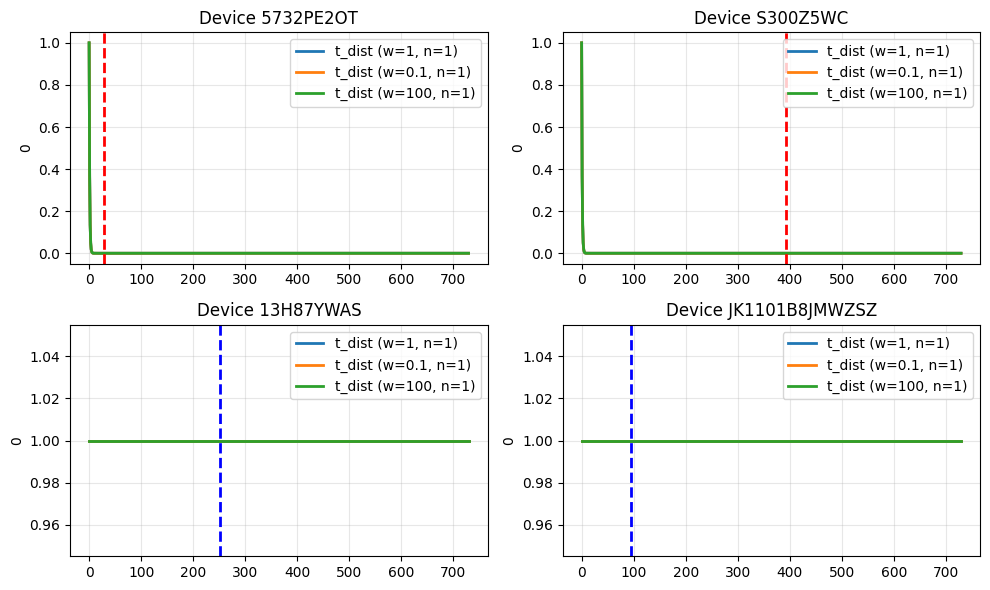

In [22]:
disks = ['5732PE2OT', 'S300Z5WC', '13H87YWAS', 'JK1101B8JMWZSZ']
t_dist_scenarios = [('t_dist', 1, 1), ('t_dist', 0.1, 1), ('t_dist', 100, 1)]
plot_agg_grid(X_pred, X_gt, serial_nums = disks, times = TIMES, agg_tuples = t_dist_scenarios, agg_observ= 10)
# plot_agg_for_observ(X_pred, X_gt, serial_num='5732PE2OT', times = TIMES, agg_tuples = t_dist_scenarios, agg_observ= 5)

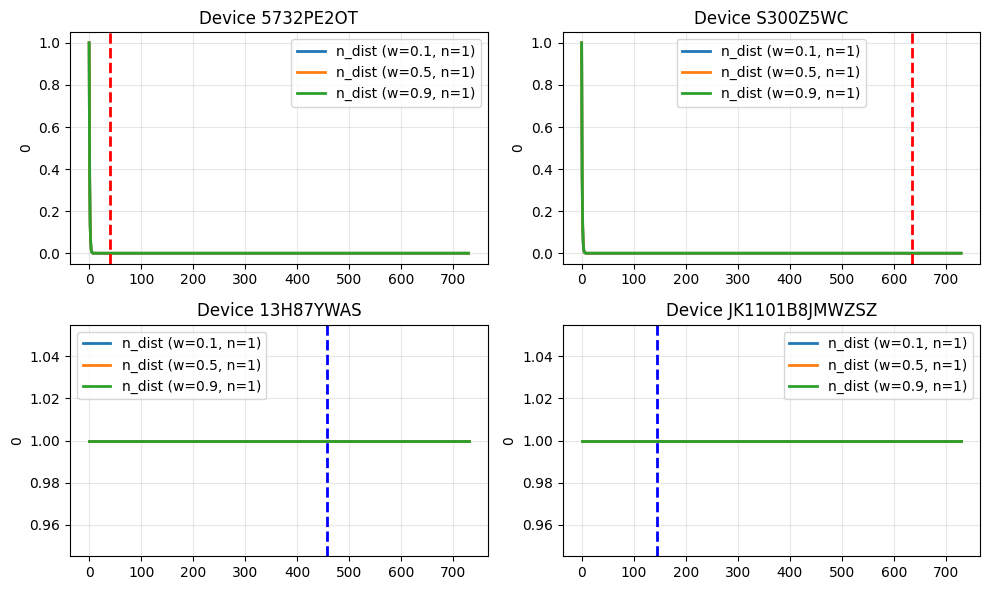

In [24]:
n_dist_scenarios = [('n_dist', 0.1, 1), ('n_dist', 0.5, 1), ('n_dist', 0.9, 1)]
plot_agg_grid(X_pred, X_gt, serial_nums = disks, times = TIMES, agg_tuples = n_dist_scenarios, agg_observ= 1)
# plot_agg_for_observ(X_pred, X_gt, serial_num='13H87YWAS', times = TIMES, agg_tuples = n_dist_scenarios, agg_observ= 5)

In [ ]:
X_pred

,serial_number,time,0,1,2,3,4,5,6,7,...,1448,1449,1450,1451,1452,1453,1454,1455,1456,1457
0,13H87YWAS,0,0.962832,0.910667,0.866551,0.847605,0.842107,0.840707,0.840408,0.840347,...,8.403319e-01,8.403319e-01,8.403319e-01,8.403319e-01,8.403319e-01,8.403319e-01,8.403319e-01,8.403319e-01,8.403319e-01,8.403319e-01
1,13H87YWAS,15,0.979713,0.965487,0.958993,0.957103,0.956604,0.956484,0.956457,0.956452,...,9.564507e-01,9.564507e-01,9.564507e-01,9.564507e-01,9.564507e-01,9.564507e-01,9.564507e-01,9.564507e-01,9.564507e-01,9.564507e-01
2,13H87YWAS,79,0.971872,0.943594,0.929010,0.924672,0.923519,0.923258,0.923204,0.923193,...,9.231908e-01,9.231908e-01,9.231908e-01,9.231908e-01,9.231908e-01,9.231908e-01,9.231908e-01,9.231908e-01,9.231908e-01,9.231908e-01
3,13H87YWAS,98,0.974808,0.951797,0.941504,0.938652,0.937930,0.937771,0.937738,0.937732,...,9.377305e-01,9.377305e-01,9.377305e-01,9.377305e-01,9.377305e-01,9.377305e-01,9.377305e-01,9.377305e-01,9.377305e-01,9.377305e-01
4,13H87YWAS,101,0.975031,0.952377,0.942362,0.939598,0.938901,0.938748,0.938717,0.938711,...,9.387093e-01,9.387093e-01,9.387093e-01,9.387093e-01,9.387093e-01,9.387093e-01,9.387093e-01,9.387093e-01,9.387093e-01,9.387093e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106667,ZCH07813,668,0.993708,0.985983,0.976037,0.963407,0.947606,0.927600,0.901105,0.866344,...,2.066352e-22,2.066352e-22,2.066352e-22,2.066352e-22,2.066352e-22,2.066352e-22,2.066352e-22,2.066352e-22,2.066352e-22,2.066352e-22
106668,ZCH07813,669,0.996602,0.992514,0.987222,0.980297,0.971339,0.959322,0.942811,0.919751,...,2.775941e-20,2.775941e-20,2.775941e-20,2.775941e-20,2.775941e-20,2.775941e-20,2.775941e-20,2.775941e-20,2.775941e-20,2.775941e-20
106669,ZCH07813,670,0.997341,0.994107,0.989938,0.984482,0.977305,0.967627,0.954111,0.934813,...,2.184055e-19,2.184055e-19,2.184055e-19,2.184055e-19,2.184055e-19,2.184055e-19,2.184055e-19,2.184055e-19,2.184055e-19,2.184055e-19
106670,ZCH07813,671,0.998880,0.997479,0.995651,0.993127,0.989530,0.984340,0.976772,0.965582,...,1.161259e-16,1.161259e-16,1.161259e-16,1.161259e-16,1.161259e-16,1.161259e-16,1.161259e-16,1.161259e-16,1.161259e-16,1.161259e-16


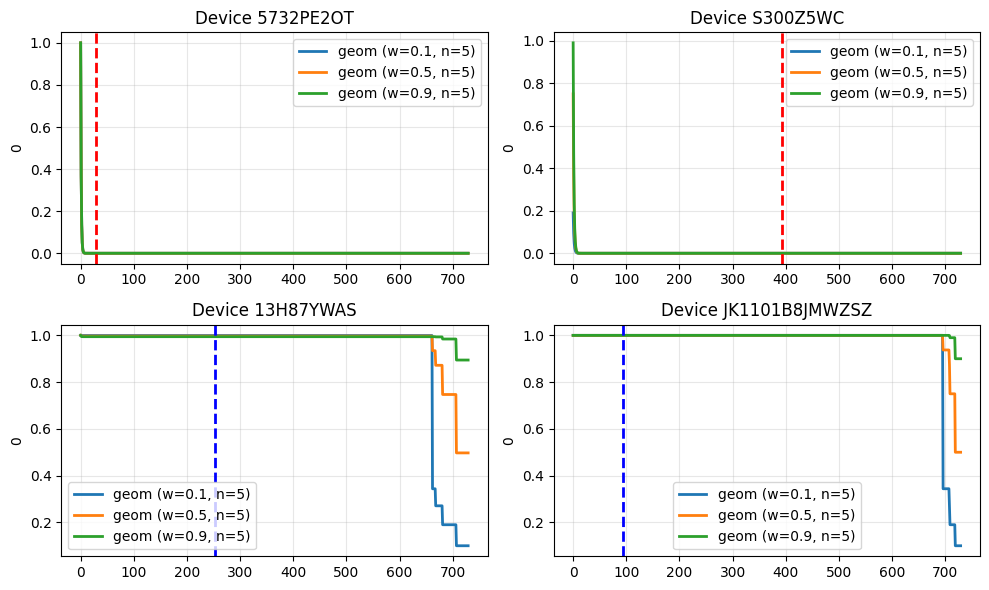

In [ ]:
geom_scenarios = [('geom', 0.1, 5), ('geom', 0.5, 5), ('geom', 0.9, 5)]
plot_agg_grid(X_pred, X_gt, serial_nums = disks, times = TIMES, agg_tuples = geom_scenarios, agg_observ= 10)
# plot_agg_for_observ(X_pred, X_gt, serial_num='13H87YWAS', times = TIMES, agg_tuples = n_dist_scenarios, agg_observ= 5)
# 5732PE2OT
# 13H87YWAS

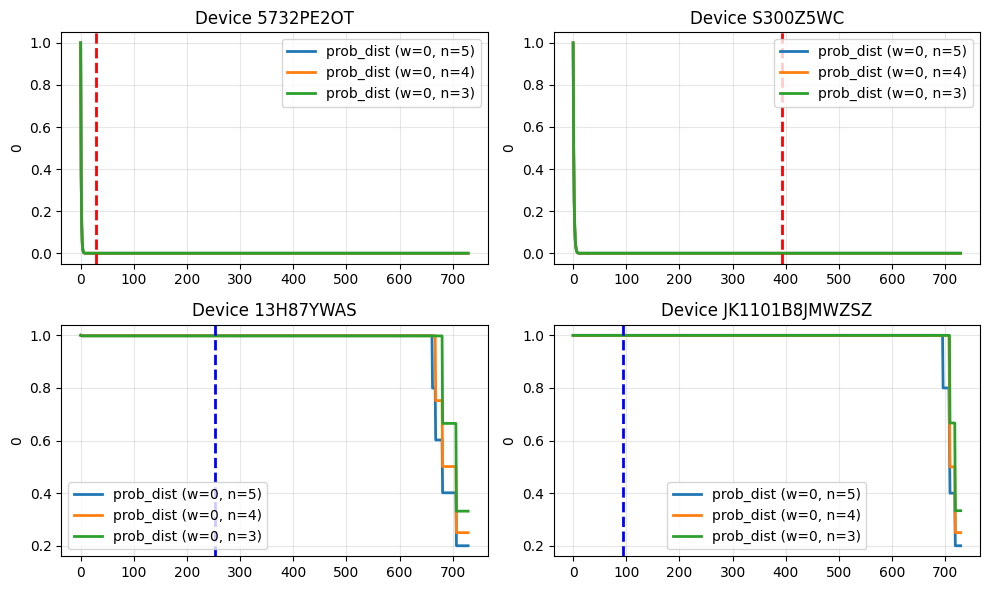

In [ ]:
prob_scenarios = [('prob_dist', 0, 5), ('prob_dist', 0, 4), ('prob_dist', 0, 3)]
plot_agg_grid(X_pred, X_gt, serial_nums = disks, times = TIMES, agg_tuples = prob_scenarios, agg_observ= 10)
# plot_agg_for_observ(X_pred, X_gt, serial_num='13H87YWAS', times = TIMES, agg_tuples = prob_scenarios, agg_observ= 5)
# 5732PE2OT
# 13H87YWAS

In [ ]:
only_failure = X_gt[(X_gt['failure'] == 1)]
only_failure[only_failure['time'] == only_failure.groupby('serial_number')['time'].transform('max')]


,serial_number,time,duration,failure
148,5732PE2OT,719,1,True
827,96ICTBQIT,416,1,True
852,9QM04GKZ,505,3,True
2513,JK1101B9J301EF,178,1,True
3347,JK1101B9JP60TU,8,1,True
...,...,...,...,...
106568,ZA189K7R,617,1,True
106599,ZA18BLFG,626,1,True
106624,ZA18BLNT,675,3,True
106633,ZCH04Y2W,677,1,True


In [ ]:
Fail_gt = X_gt[X_gt['failure'] == True]
Fail_gt = Fail_gt.groupby('serial_number').head(10)
Fail_gt = Fail_gt.groupby('serial_number').tail(1)
Fail_gt['duration'].sort_values()

106281      1
89134       1
90840       1
106633      1
99646       1
         ... 
91184     522
76080     526
88831     535
103098    574
77387     623
Name: duration, Length: 581, dtype: int32

In [ ]:
cur_disk = np.random.choice(X_pred[X_gt['failure']]['serial_number'].unique())
print(cur_disk)
X_cur_pred = X_pred[X_pred['serial_number'] == cur_disk].head(5)
X_cur_gt = X_gt[X_gt['serial_number'] == cur_disk].head(5)
event = X_cur_gt.iloc[-1, -1]
duration = X_cur_gt.iloc[-1, -2]
# Z1Z058J5
# 45CHK11WFMYB

S3010LH1


In [ ]:
import matplotlib.pyplot as plt
def plot_predictions(pred, times, event, duration):
    sns.lineplot(x=times, y=pred)
    if event:
        plt.axvline(x=duration, color='r', label='axvline - full height')
    else:
        plt.axvline(x=duration, color='b', label='axvline - full height')

In [ ]:
X_cur_pred

,serial_number,time,0,1,2,3,4,5,6,7,...,1448,1449,1450,1451,1452,1453,1454,1455,1456,1457
75119,S3010LH1,0,0.412048,0.170044,0.070241,0.029062,0.011979,0.004900,0.001977,0.000787,...,1.995456e-22,1.995456e-22,1.995456e-22,1.995456e-22,1.995456e-22,1.995456e-22,1.995456e-22,1.995456e-22,1.995456e-22,1.995456e-22
75120,S3010LH1,12,0.425908,0.181140,0.077047,0.032787,0.013942,0.005898,0.002472,0.001024,...,1.276876e-28,1.276876e-28,1.276876e-28,1.276876e-28,1.276876e-28,1.276876e-28,1.276876e-28,1.276876e-28,1.276876e-28,1.276876e-28
75121,S3010LH1,15,0.408179,0.166716,0.068175,0.027933,0.011403,0.004627,0.001855,0.000735,...,2.063027e-23,2.063027e-23,2.063027e-23,2.063027e-23,2.063027e-23,2.063027e-23,2.063027e-23,2.063027e-23,2.063027e-23,2.063027e-23
75122,S3010LH1,44,0.412818,0.171201,0.071404,0.029869,0.012478,0.005186,0.002135,0.000869,...,1.154386e-26,1.154386e-26,1.154386e-26,1.154386e-26,1.154386e-26,1.154386e-26,1.154386e-26,1.154386e-26,1.154386e-26,1.154386e-26
75123,S3010LH1,47,0.426035,0.181515,0.077485,0.033142,0.014166,0.006026,0.002539,0.001057,...,6.164401e-29,6.164401e-29,6.164401e-29,6.164401e-29,6.164401e-29,6.164401e-29,6.164401e-29,6.164401e-29,6.164401e-29,6.164401e-29


In [ ]:
X_cur_gt

,serial_number,time,duration,failure
75119,S3010LH1,0,484,True
75120,S3010LH1,12,472,True
75121,S3010LH1,15,469,True
75122,S3010LH1,44,440,True
75123,S3010LH1,47,437,True


In [ ]:
plot_predictions(X_cur_pred.iloc[0, 2:], TIMES, event, duration)

ValueError: array length 730 does not match index length 1458

In [ ]:
pred_agg = PredictionsAggregator(mode='n_dist')
extended_times = pred_agg.get_extended_times(X_cur_pred, times = TIMES)

In [ ]:
X_predicted_duration = pred_agg.get_expected_time_by_predictions(X_pred[X_gt['failure'] == 1], times=TIMES)
X_pred[X_gt['failure'] == 1][( X_predicted_duration > 100)]

,serial_number,time,0,1,2,3,4,5,6,7,...,720,721,722,723,724,725,726,727,728,729
412,9QM04GKZ,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
413,9QM04GKZ,86,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
414,9QM04GKZ,142,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
415,9QM04GKZ,233,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
416,9QM04GKZ,316,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
417,9QM04GKZ,330,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
418,9QM04GKZ,348,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
419,9QM04GKZ,477,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
420,9QM04GKZ,483,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
421,9QM04GKZ,505,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
X_no_agg_predict = model.get_expected_time_by_predictions(X_pred[X_gt['failure'] == 1], times=TIMES)

In [ ]:
(X_gt[X_gt['failure'] == 1]['duration'] - X_predicted_duration).median()

112.60177783010822

In [ ]:
(X_gt[X_gt['failure'] == 1]['duration'] - X_no_agg_predict).mean()


163.160056689063

Metriki s axis

In [39]:
from lifelines.utils import concordance_index  # type: ignore
from survivors.metrics import ibs_remain

def bal_ibs_remain(survival_train, survival_test, estimate, times, axis=-1):
    """ IBS with equal impact of each event type and partial observation with controlled quantity """
    ibs_event = ibs_remain(survival_train, survival_test[survival_test["event"]],
                            estimate[survival_test["event"]], times, axis=axis)
    ibs_cens = ibs_remain(survival_train, survival_test[~survival_test["event"]],
                            estimate[~survival_test["event"]], times, axis=axis)
    return (ibs_event + ibs_cens)/2

def get_ci_ibs_ibs_bal(model, df_pred: pd.DataFrame, df_gt: pd.DataFrame, times: np.ndarray, axis=-1):
    """Calculate Concordance Index (CI) and Integrated Brier Score (IBS).

    Args:
        model: The trained model used for predictions.
        df_pred (pd.DataFrame): DataFrame containing predicted survival functions.
        df_gt (pd.DataFrame): DataFrame containing ground truth durations and event indicators.
        times (np.ndarray): Array of time points for evaluation.

    Returns:
        Tuple[float, float, float]: Concordance Index (CI), Integrated Brier Score (IBS) and balanced IBS.
    """
    survival_test = pd.DataFrame()
    survival_test['event'] = df_gt['failure'].astype(bool)
    survival_test['duration'] = df_gt['duration']

    lifetime_pred = model.get_expected_time_by_predictions(df_pred, times)

    ci = concordance_index(df_gt['duration'], lifetime_pred, df_gt['failure'])

    survival_estim = df_pred.drop(['serial_number', 'time'], axis='columns')
    ibs = ibs_remain(
        None,
        survival_test.to_records(index=False),
        survival_estim,
        times,
        axis=axis
    )

    ibs_bal = bal_ibs_remain(
        None,
        survival_test.to_records(index=False),
        survival_estim,
        times,
        axis=-1
    )

    return ci, ibs, ibs_bal

In [ ]:
ci_orig, ibs_orig, ibs_bal_orig = get_ci_ibs_ibs_bal(model, X_pred, X_gt, TIMES, axis = 1)

In [40]:
_, ibs_along_time, ibs_bal_time = get_ci_ibs_ibs_bal(model, X_pred, X_gt, TIMES, axis = 1)
_, ibs_along_obs, ibs_bal_obs = get_ci_ibs_ibs_bal(model, X_pred, X_gt, TIMES, axis = 0)


<Axes: ylabel='Density'>

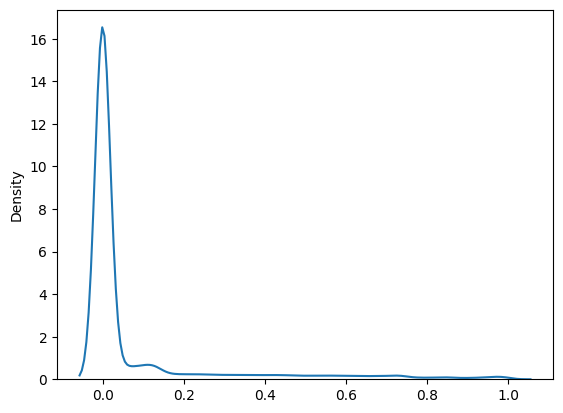

In [80]:
import seaborn as sns
sns.kdeplot(ibs_along_obs)

In [43]:
ibs_along_obs

array([0.        , 0.        , 0.        , ..., 0.00386021, 0.00253872,
       0.00130357])

In [47]:
X_predicted_duration = pd.Series(pred_agg.get_expected_time_by_predictions(X_pred, times=TIMES))
pd.concat([X_predicted_duration, X_gt], axis = 1)

,0,serial_number,time,duration,failure
0,729.000000,13H87YWAS,0,473,False
1,729.000000,13H87YWAS,15,458,False
2,729.000000,13H87YWAS,79,394,False
3,729.000000,13H87YWAS,98,375,False
4,729.000000,13H87YWAS,101,372,False
...,...,...,...,...,...
106667,0.398037,ZCH07813,668,5,True
106668,0.398037,ZCH07813,669,4,True
106669,0.398037,ZCH07813,670,3,True
106670,0.398037,ZCH07813,671,2,True


<Axes: ylabel='Density'>

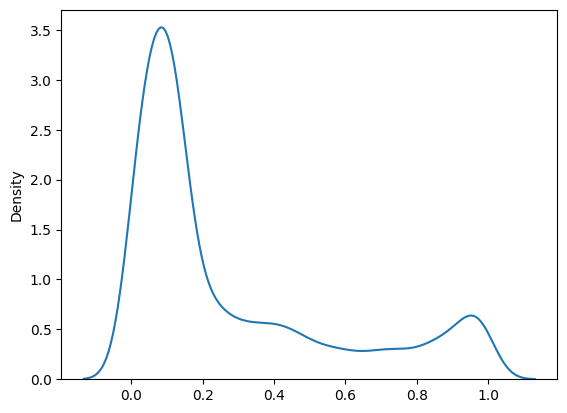

In [82]:
sns.kdeplot(ibs_along_obs[X_gt['failure'] == 1])
# sns.kdeplot(ibs_along_obs[X_gt['failure'] == 0])

<Axes: ylabel='Density'>

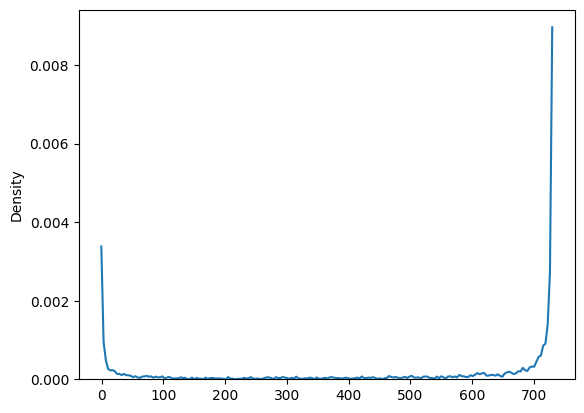

In [56]:
sns.kdeplot(X_predicted_duration, bw_adjust=0.01)

In [58]:
X_pred_alpha = X_pred.copy()

In [78]:
X_pred_alpha.iloc[:,2:] = np.power(X_pred_alpha.iloc[:,2:], 1/100)

In [62]:
X_pred_alpha

,serial_number,time,0,1,2,3,4,5,6,7,...,720,721,722,723,724,725,726,727,728,729
0,13H87YWAS,0,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,13H87YWAS,15,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,13H87YWAS,79,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,13H87YWAS,98,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,13H87YWAS,101,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106667,ZCH07813,668,0.606531,0.367879,0.22313,0.135335,0.082085,0.049787,0.030197,0.018316,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106668,ZCH07813,669,0.606531,0.367879,0.22313,0.135335,0.082085,0.049787,0.030197,0.018316,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106669,ZCH07813,670,0.606531,0.367879,0.22313,0.135335,0.082085,0.049787,0.030197,0.018316,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106670,ZCH07813,671,0.606531,0.367879,0.22313,0.135335,0.082085,0.049787,0.030197,0.018316,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [79]:
ci, ibs, ibs_bal = get_ci_ibs_ibs_bal(model, X_pred_alpha, X_gt, TIMES, axis = -1)
_, ibs_along_time, ibs_bal_time = get_ci_ibs_ibs_bal(model, X_pred_alpha, X_gt, TIMES, axis = 1)
_, ibs_along_obs, ibs_bal_obs = get_ci_ibs_ibs_bal(model, X_pred_alpha, X_gt, TIMES, axis = 0)


In [77]:
ci, ibs, ibs_bal

(0.8122432908109689, 0.20489071604815445, 0.266588997189827)

In [ ]:
(0.8123764106309257, 0.22409527996518924, 0.29780311535679926)
(0.8124719078656384, 0.22045259630804995, 0.29326936941945886) 1/2
(0.8121240792178754, 0.2077528621221147, 0.2740496609050911) 1/10
(0.8120015228893535, 0.2040314361169163, 0.2650900094441945) 1/100
(0.8122432908109689, 0.20489071604815445, 0.266588997189827) 1/1000